<a href="https://colab.research.google.com/github/esunn0412/qtm151_fall_2023/blob/main/CS444_Assignment2_GNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS444 Assignment 2: Graph Neural Networks


Welcome to your second homework assignment in `CS444 Deep Learning course`. In this assignment we will implement the **GraphSAGE** ([Hamilton et al. (2017)](https://arxiv.org/abs/1706.02216)) layer and **GAT** ([Veličković et al. (2018)](https://arxiv.org/abs/1710.10903)) layer. Then we will run our models on the CORA dataset, which is a standard node classification dataset on a citation network benchmark.

## Objectives
By the end of this assignment, you will be able to:
1. Understand the principles of Graph Neural Networks (GNNs) and their applications.
2. Implement basic GNN layers including GraphSAGE and Graph Attention Network (GAT).
3. Train and evaluate GNN models on a given dataset.
4. Experiment with hyperparameters tuning to see their influences on model performance.



## What you need to do:
1. Go through the entire notebook and implement all the missing code, which are marked with **`'TODO'`**.
2. Implement the necessary functions and classes as described.
3. Train and evaluate your models.
4. Answer the questions at the end of the notebook.
5. Submit the completed notebook, along with all other generated files. <font color='red'> The uploaded .ipynb notebook should contain **completed codes** and all **cell output**. </font>


**Note**: Make sure to **sequentially run all the cells in each section** so that the intermediate variables / packages will carry over to the next cell.

**Device**: We recommend using a GPU for this assignment. Google Colab provides free access to GPUs, but there are usage limits. If your account still has GPU usage time available, you can enable GPU as follows: click `Runtime` and then `Change runtime type`. Then set the `hardware accelerator` to GPU. **Don't worry if you run out of GPU usage quota or don't have access to one. The dataset and model size for this assignment are not very large, and using a CPU will also work fine.**.

<br>

---



## Part 1: Install the necessary libraries

In this assignment, we will primarily use [PyTorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/), a library built on top of PyTorch to easily handle and perform operations on geometric data, such as graphs. PyTorch Geometric provides various methods to efficiently work with graph-structured data and implement graph neural networks (GNNs). This library will allow us to implement and experiment with GNN models like GraphSAGE and GAT.
<br><br>


<font color='red'> Before you start coding, it is highly recommended to review the [basics of PyTorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/get_started/introduction.html). This will prepare you for implementing GAT and GraphSAGE on your own. </font>


Below are the steps to install the required libraries. This may take a few minutes to install (depending on your network environment).

In [ ]:
# Install torch geometric
import os
!pip install torch-scatter -f https://pytorch-geometric.com/whl/torch-1.9.0+cu111.html
!pip install torch-sparse -f https://pytorch-geometric.com/whl/torch-1.9.0+cu111.html
!pip install torch-geometric

Looking in links: https://pytorch-geometric.com/whl/torch-1.9.0+cu111.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import torch_geometric

# check the version of installed PyG (PyTorch Geometric)
torch_geometric.__version__

'2.7.0'

## Part 2: Implementing Graph Neural Networks

For this assignment, we provide a general Graph Neural Network (GNN) stack, into which you will be able to plug in your own **`Layer Module implementations`** of `GraphSAGE` and `GAT` models.

We will then use our layer implemenations to complete node classification on the **`CORA dataset`**, a standard citation network benchmark. In this dataset, `nodes` correspond to documents and `edges` correspond to undirected citations. Each node or document in the graph is assigned a class label and features based on the documents binarized bag-of-words representation. Specifically, the Cora dataset has **only 1 graph**, which has 2708 nodes, 5429 edges, 7 prediction classes, and 1433 features per node.

### 2.1 GNN Stack Module

Below is the implementation of a general GNN stack, where we can plugin any GNN layer, such as **GraphSage**, **GAT**, etc. This module is provided for you. Your implementations of the **GraphSage** and **GAT** layers will function as components in the GNNStack Module.

In [ ]:
import torch
import torch_scatter
import torch.nn as nn
import torch.nn.functional as F

import torch_geometric.nn as pyg_nn
import torch_geometric.utils as pyg_utils

from torch import Tensor
from typing import Union, Tuple, Optional
from torch_geometric.typing import (OptPairTensor, Adj, Size, NoneType,
                                    OptTensor)

from torch.nn import Parameter, Linear
from torch_sparse import SparseTensor, set_diag
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.utils import remove_self_loops, add_self_loops, softmax

class GNNStack(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, args, emb=False):
        super(GNNStack, self).__init__()
        conv_model = self.build_conv_model(args.model_type)
        self.convs = nn.ModuleList()

        assert (args.num_layers >= 1), 'Number of layers is not >=1'

        if args.model_type == 'GraphSage':
          self.convs.append(conv_model(input_dim, hidden_dim))
          for l in range(args.num_layers-1):
              self.convs.append(conv_model(hidden_dim, hidden_dim))

        elif args.model_type == 'GAT':
          self.convs.append(conv_model(input_dim, hidden_dim, args.heads, dropout = args.dropout))
          for l in range(args.num_layers-1):
              self.convs.append(conv_model(args.heads * hidden_dim, hidden_dim, args.heads, dropout = args.dropout))


        # post-message-passing
        self.post_mp = nn.Sequential(
            nn.Linear(args.heads * hidden_dim, hidden_dim), nn.Dropout(args.dropout),
            nn.Linear(hidden_dim, output_dim))

        self.dropout = args.dropout
        self.num_layers = args.num_layers

        self.emb = emb

    def build_conv_model(self, model_type):
        if model_type == 'GraphSage':
            return GraphSage
        elif model_type == 'GAT':
            return GAT

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout,training=self.training)

        x = self.post_mp(x)

        if self.emb == True:
            return x

        return F.log_softmax(x, dim=1)

    def loss(self, pred, label):
        return F.nll_loss(pred, label)

### 2.2 Creating Our Own Message Passing Layer

Now let's start implementing our own message passing layers! Working through this part will help us become familiar with the inner workings of PyTorch Message Passing Layers, allowing us to build our own GNN models. To do this, we will implement three critical functions needed to define a PyG Message Passing Layer: **`forward`**, **`message`**, and **`aggregate`**.

Before diving head first into the coding details, let us quickly review the key components of the message passing process. To do so, we will focus on a single round of messsage passing with respect to a single central node $x$. Before message passing, $x$ is associated with a feature vector $x^{l-1}$, and the goal of message passing is to update this feature vector as $x^l$. To do so, we implement the following steps: **1)** each neighboring node $v$ passes its current message $v^{l-1}$ across the edge $(x, v)$. **2)** for the node $x$, we aggregate all of the messages of the neighboring nodes (for example through a sum or mean), and **3)** we transform the aggregated information, for example by applying linear and non-linear transformations. Altogether, the message passing process is applied such that every node $u$ in our graph updates its embedding by acting as the central node $x$ in step 1-3 described above.

Now, we extend this process to that of a single message passing layer, the job of a message passing layer is to update the current feature representation or embedding of each node in a graph by propagating and transforming information within the graph. Overall, the general paradigm of a message passing layers is: 1) pre-processing -> 2) **message passing** / propagation -> 3) post-processing.

The **`forward`** fuction that we will implement for our message passing layer captures this execution logic. Namely, the `forward` function handles the pre and post-processing of node features / embeddings, as well as initiates message passing by calling the `propagate` function.


The **`propagate`** function encapsulates the message passing process! It does so by **calling three important functions**: 1) **`message`**, 2) **`aggregate`**, and 3) `update`. Our implementation will vary slightly from this, as we will not explicitly implement `update`, but instead place the logic for updating node embeddings after message passing and within the `forward` function, which serves as post-processing part of `forward` function. To be more specific, after information is propagated (message passing), we can further transform the node embeddings outputed by `propagate`. Therefore, the output of `forward` is exactly the node embeddings after one GNN layer.

Lastly, before starting to implement our own layer, let us dig a bit deeper into each of the functions described above:



```
1. def propagate(edge_index, x):
```

Calling `propagate` initiates the message passing process. Let's break down the key parameters of this function:

  - `edge_index`: This parameter is a tensor of shape `[2, num_edges]` that defines the graph's connectivity. Each column of `edge_index` represents a directed edge between two nodes, where the first row is the source node and the second row is the target node. For example, an edge between node `i` and node `j` would be represented as a column with `edge_index[:, k] = [i, j]`.

  - `x`: This parameter represents the node features used in message passing. It can be either `a single tensor` or a tuple of tensors `(x_i, x_j)`. When `x` is a tuple `(x_i, x_j)`, it allows us to explicitly differentiate between the central (source) node features `x_i` and the neighboring (target) node features `x_j`.
    - If `x` is a `single tensor` (e.g., `x`), it means we are using the same features for both the central and neighboring nodes. This is typically the case when we are only interested in the node embeddings themselves without any distinction between central and neighboring nodes.

    - When `x` is a `tuple (x_i, x_j)`, it provides a way to handle cases where we need to differentiate between the features of source nodes and target nodes during message passing. This is especially useful when implementing specific message passing mechanisms where source and target nodes contribute differently to the final node embeddings.

    To explain why we pass the tuple `(x_i, x_j)`, we need to understand how edges are represented. For every edge $(i, j) \in E$, $i$ is the source or central node ($x_{central}$) and $j$ is the neighboring node ($x_{neighbor}$).

    Taking the example of message passing, for a central node $i$, we aggregate and transform all messages associated with the nodes $j$ such that $(i, j) \in E$ (i.e., $j \in N_{i}$). Thus, the subscripts `_i` and `_j` allow us to specifically differentiate features associated with central nodes (nodes receiving message information) and neighboring nodes (nodes passing messages).

    This concept can be confusing. However, one key point to remember is that depending on the perspective, a node can act as a central node or a neighboring node. In undirected graphs, we store both edge directions (i.e., $(i, j)$ and $(j, i)$). From the central node perspective, node $i$ is collecting neighboring information to update its embedding. From the neighboring node perspective, node $j$ is passing its message information along the edge connecting it to a different central node.

  
  The output of the `propagate` function is a matrix of node embeddings after the message passing process and has shape `[N, d]`, where `N` is the number of nodes and `d` is the dimensionality of the embeddings.

  **Note**: In this assignment, we don't need to redefine the `propagate` function. Instead, we only need to define the corresponding `message` and `aggregate` functions that propagate calls.



```
2. def message(x_j, ...):
```
The `message` function is called by propagate and constructs the messages from
neighboring nodes $j$ to central nodes $i$ for each edge $(i, j)$ in *edge_index*. This function can take any argument that was initially passed to `propagate`. Furthermore, we can again differentiate central nodes and neighboring nodes by appending `_i` or `_j` to the variable name, .e.g. `x_i` and `x_j`. Looking more specifically at the variables, we have:

  - `x_j` represents a matrix of feature embeddings for all neighboring nodes passing their messages along their respective edge (i.e. all nodes $j$ for edges $(i, j) \in E$). Thus, its shape is $[|E|, d]$.
  - In implementing GAT we will see how to access additional variables passed to propagate

  Critically, we see that the output of the `message` function is a matrix of neighboring node embeddings ready to be aggregated, having shape $[|E|, d]$.


```
3. def aggregate(self, inputs, index, dim_size = None):
```
Lastly, The `aggregate` function is used to combine the messages from neighboring nodes. Let's break down its parameters:

- `inputs`: This represents a matrix of messages passed from neighboring nodes (i.e., the output of the `message` function). Each row corresponds to a message from a neighboring node. The shape of `inputs` is `[num_messages, d]`, where `num_messages` is the number of messages (which typically equals the number of edges in the graph), and `d` is the dimensionality of the messages.
- `index`: This tensor has the same number of elements as `inputs` and indicates which central node each message in `inputs` corresponds to. Essentially, `index` specifies the indices of the central nodes that each message should be aggregated to. The shape of `index` is `[num_messages]`. For example, if `index[j] = i`, it means the `j`-th message in `inputs` should be aggregated to the `i`-th central node.
- `dim_size`: This optional parameter specifies the size of the output along the dimension that we are aggregating. It is typically used to ensure the output has the correct shape, especially when dealing with batches or variable-sized graphs. If not provided, it can be inferred as the maximum value in `index` plus one, i.e., `max(index) + 1`.

The output of the `aggregate` function is a matrix of shape `[N, d]`, where `N` is the number of central nodes and `d` is the dimensionality of the node features. This matrix contains the aggregated messages for each central node.

<br>

For additional resources refer to the PyG documentation for implementing custom message passing layers: https://pytorch-geometric.readthedocs.io/en/latest/notes/create_gnn.html

### 2.3 GraphSage Implementation

For our first GNN layer, we will implement the well known GraphSage ([Hamilton et al. (2017)](https://arxiv.org/abs/1706.02216)) layer!

For a given *central* node $v$ with current embedding $h_v^{l-1}$, the message passing update rule to tranform $h_v^{l-1} \rightarrow h_v^l$ is as follows:

\begin{equation}
h_v^{(l)} = W_l\cdot h_v^{(l-1)} + W_r \cdot AGG(\{h_u^{(l-1)}, \forall u \in N(v) \})
\end{equation}

where $W_l$ and $W_r$ are learanble weight matrices and the nodes $u$ are *neighboring* nodes of *central* node $v$. Additionally, we use mean aggregation for simplicity:

\begin{equation}
AGG(\{h_u^{(l-1)}, \forall u \in N(v) \}) = \frac{1}{|N(v)|} \sum_{u\in N(v)} h_u^{(l-1)}
\end{equation}

One thing to note is that we're adding a **skip connection** to our GraphSage implementation through the term $W_l\cdot h_v^{(l-1)}$.

Before implementing this update rule, we encourage you to think about how different parts of the formulas above correspond with the functions outlined earlier: 1) `forward`, 2) `message`, and 3) `aggregate`. As a hint, we are given what the aggregation function is (i.e. mean aggregation)! Now the question remains, what are the messages passed by each neighbor nodes and when do we call the `propagate` function?

Note: in this case the message function or messages are actually quite simple. Additionally, remember that the `propagate` function encapsulates the operations of / the outputs of the combined `message` and `aggregate` functions.


Lastly, $\ell$-2 normalization of the node embeddings is applied after each iteration.


<font color='red'>For the following questions, please DON'T refer to any existing implementations online.</font>

In [ ]:
class GraphSage(MessagePassing):

    def __init__(self, in_channels, out_channels, normalize = True,
                 bias = False, **kwargs):
        super(GraphSage, self).__init__(**kwargs)

        ############################################################################
        # TODO: Your code here!
        # Define the layers needed for the message and update functions below.
        # Hint: You need two linear layers (nn.linear) for the W_l and W_r
        ############################################################################
        self.lin_l = nn.Linear(in_channels, out_channels, bias=bias)
        self.lin_r = nn.Linear(in_channels, out_channels, bias=bias)
        self.normalize = normalize

        self.reset_parameters()


    def reset_parameters(self):
        self.lin_l.reset_parameters()
        self.lin_r.reset_parameters()


    def forward(self, x, edge_index, size = None):
        ############################################################################
        # TODO: Your code here!
        # Implement message passing, as well as any post-processing (our update rule).
        # 1. Call the propagate function to conduct the message passing.
        #    1.1 See the description of propagate above or the following link for more information:
        #        https://pytorch-geometric.readthedocs.io/en/latest/notes/create_gnn.html
        #    1.2 We will use the same features for both the central and neighboring nodes, so by default
        #        we pass the node feature parameters as x=x.
        # 2. Update our node embedding with skip connection from the previous layer.
        # 3. If normalize is set, do L-2 normalization (defined in
        #    torch.nn.functional)
        #
        ############################################################################
        # x = [N, in_channel]
        # edge_index = [2, E]

        mean = self.propagate(edge_index, x=x, size=size)
        out = self.lin_l(x) + self.lin_r(mean)
        if self.normalize:
            out = F.normalize(out, p=2, dim=-1) # normalize by feature
        return out



    def message(self, x_j):
        ############################################################################
        # TODO: Your code here!
        # Implement your message function here.
        # Hint: Look at the formulation of the mean aggregation function, focusing on
        # what message each neighboring node passes.
        ############################################################################
        # shape is [E, in   channel]
        return x_j



    def aggregate(self, inputs, index, dim_size = None):

        ############################################################################
        # TODO: Your code here!
        # Implement your aggregate function here.
        # See here as how to use torch_scatter.scatter:
        # https://pytorch-scatter.readthedocs.io/en/latest/functions/scatter.html#torch_scatter.scatter
        ############################################################################
        return torch_scatter.scatter(inputs, index, dim=0, dim_size=dim_size, reduce='mean')




### 2.4 GAT Implementation

Attention mechanisms have become the state-of-the-art in many sequence-based tasks such as machine translation and learning sentence representations. One of the major benefits of attention-based mechanisms is their ability to focus on the most relevant parts of the input to make decisions. In this problem, we will see how attention mechanisms can be used to perform node classification over graph-structured data through the usage of Graph Attention Networks (GATs) ([Veličković et al. (2018)](https://arxiv.org/abs/1710.10903)).

The building block of the Graph Attention Network is the graph attention layer, which is a variant of the aggregation function. Let $ N $ be the number of nodes and $ F $ be the dimension of the feature vector for each node. The input to each graph attentional layer is a set of node features: $ \mathbf{h} = \{\overrightarrow{h_1}, \overrightarrow{h_2}, \dots, \overrightarrow{h_N}\} $, where $ \overrightarrow{h_i} \in \mathbb{R}^F $. The output of each graph attentional layer is a new set of node features, which may have a new dimension $ F' $: $ \mathbf{h'} = \{\overrightarrow{h_1'}, \overrightarrow{h_2'}, \dots, \overrightarrow{h_N'}\} $, with $ \overrightarrow{h_i'} \in \mathbb{R}^{F'} $.

We will now describe how this transformation is performed for each graph attention layer. First, a shared linear transformation parameterized by the weight matrix $ \mathbf{W} \in \mathbb{R}^{F' \times F} $ is applied to every node.

Next, we perform self-attention on the nodes. We use a shared attention function $ a $:
\begin{equation}
a : \mathbb{R}^{F'} \times \mathbb{R}^{F'} \rightarrow \mathbb{R}
\end{equation}
that computes the attention coefficients capturing the importance of node $ j $'s features to node $ i $:
\begin{equation}
e_{ij} = a(\mathbf{W} \overrightarrow{h_i}, \mathbf{W} \overrightarrow{h_j})
\end{equation}



The most general formulation of self-attention allows every node to attend to all other nodes which drops all structural information. However, to utilize graph structure in the attention mechanisms, we use **masked attention**. In masked attention, we only compute attention coefficients $ e_{ij} $ for nodes $ j \in N_i $ where $ N_i $ is the set of neighborhood of node $ i $ in the graph.

To easily compare coefficients across different nodes, we normalize the coefficients across $ j $ using a softmax function:
\begin{equation}
\alpha_{ij} = \text{softmax}_j(e_{ij}) = \frac{\exp(e_{ij})}{\sum_{k \in N_i} \exp(e_{ik})}
\end{equation}

For this problem, our attention mechanism $ a $ will be a single-layer feedforward neural network parameterized by a weight vector $ \overrightarrow{a} \in \mathbb{R}^{2F'} $, followed by a LeakyReLU nonlinearity (with negative input slope 0.2). Specifically, weight vector $\overrightarrow{a}$ could be decomposed as $\overrightarrow{a}=[\overrightarrow{a_l}, \overrightarrow{a_r} ]$, where $ \overrightarrow{a_l} \in \mathbb{R}^{F'} $ and $ \overrightarrow{a_r} \in \mathbb{R}^{F'} $. Let $ \cdot^T $ represent transposition and $ || $ represent concatenation. The coefficients computed by our attention mechanism may be expressed as:

\begin{equation}
\begin{aligned}
\alpha_{ij} &= \frac{\exp\left(\text{LeakyReLU}\left(\overrightarrow{a}^T \left[\mathbf{W} \overrightarrow{h_i} || \mathbf{W} \overrightarrow{h_j}\right]\right)\right)}{\sum_{k \in N_i} \exp\left(\text{LeakyReLU}\left(\overrightarrow{a}^T \left[\mathbf{W} \overrightarrow{h_i} || \mathbf{W} \overrightarrow{h_k}\right]\right)\right)} \\
&= \frac{\exp\left(\text{LeakyReLU}\left(\overrightarrow{a_l}^T \mathbf{W} \overrightarrow{h_i} + \overrightarrow{a_r}^T \mathbf{W} \overrightarrow{h_j}\right)\right)}{\sum_{k \in N_i} \exp\left(\text{LeakyReLU}\left(\overrightarrow{a_l}^T \mathbf{W} \overrightarrow{h_i} + \overrightarrow{a_r}^T \mathbf{W} \overrightarrow{h_k}\right)\right)}
\end{aligned}
\end{equation}

At every layer of GAT, after the attention coefficients are computed for that layer, the aggregation function can be computed by a weighted sum of neighborhood messages, where weights are specified by $ \alpha_{ij} $.

Now, we use the normalized attention coefficients to compute a linear combination of the features corresponding to them. These aggregated features will serve as the final output features for every node.

\begin{equation}
h_i' = \sum_{j \in N_i} \alpha_{ij} \mathbf{W} \overrightarrow{h_j}
\end{equation}

At this point, we have covered a lot of information! Before reading further about multi-head attention, we encourage you to go again through the exercise of thinking about what components of the attention mechanism correspond with the different functions: 1) `forward`, 2) `message`, and 3) `aggregate`.

- Hint 1: Our aggregation is similar to that of GraphSage, except we are using attention-weighted sum aggregation.
- Hint 2: The terms we aggregate represent the individual messages that each neighbor node $ j $ sends. Thus, $ \alpha_{ij} $ is part of the message each node sends and is computed during the `message` step. This makes sense since an attention weight is associated with each edge in the graph.
- Hint 3: Look at the terms in the definition of $ \alpha_{ij} $. Consider what values you want to preprocess and pass as parameters to the `propagate` function. The parameters of `message(..., x_j, alpha_j, alpha_i, ...)` should give a good hint.

### Multi-Head Attention
To stabilize the learning process of self-attention, we use multi-head attention. To do this, we use $ K $ independent attention mechanisms, or "heads", to compute output features as described in the equations above. Then, we concatenate these output feature representations:

\begin{equation}
\overrightarrow{h_i}' = ||_{k=1}^K \Big(\sum_{j \in N_i} \alpha_{ij}^{(k)} \mathbf{W}^{(k)} \overrightarrow{h_j}\Big)
\end{equation}

where $ || $ denotes concatenation, $ \alpha_{ij}^{(k)} $ are the normalized attention coefficients computed by the $ k $-th attention mechanism $ a^k $, and $ \mathbf{W}^{(k)} $ is the corresponding input linear transformation's weight matrix. Note that for this setting, $ \mathbf{h'} \in \mathbb{R}^{KF'} $.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax
import torch_scatter

class GAT(MessagePassing):

    def __init__(self, in_channels, out_channels, heads=2,
                 negative_slope=0.2, dropout=0., **kwargs):
        super(GAT, self).__init__(node_dim=0, **kwargs)

        ############################################################################
        # TODO: Your code here!
        # Define the layers needed for the message functions below.
        #
        # Hint:
        # 1. Define a single linear transformation layer to transform node features.
        #    This layer should map from in_channels to out_channels * heads since we
        #    are using Multi-head attention.
        # 2. Define two learnable parameter vectors, att_l and att_r, which will be
        #    used to compute the attention coefficients. Each should have shape
        #    [1, heads, out_channels].
        # 3. Initialize the parameters by calling reset_parameters.
        ############################################################################
        self.lin = nn.Linear(in_channels, out_channels * heads, bias=False)
        self.att_l = nn.Parameter(torch.Tensor(1, heads, out_channels))
        self.att_r = nn.Parameter(torch.Tensor(1, heads, out_channels))
        self.reset_parameters()
        self.negative_slope = negative_slope
        self.dropout = dropout
        self.heads = heads
        self.out_channels = out_channels


    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin.weight)
        nn.init.xavier_uniform_(self.att_l)
        nn.init.xavier_uniform_(self.att_r)


    def forward(self, x, edge_index, size=None):
        ############################################################################
        # TODO: Your code here!
        # Implement message passing, as well as any pre- and post-processing (our update rule).
        #
        # Hint:
        # 1. Apply the linear transformation to node embeddings, and split that
        #    into multiple heads. We use the same representations for source and
        #    target nodes, and apply same linear weights W.
        # 2. Compute alpha vectors for central nodes (alpha_l) and neighbor nodes (alpha_r)
        #    by taking the dot product of transformed node embeddings with the
        #    corresponding attention vectors.
        # 3. Call the propagate function to conduct message passing.
        #    3.1 Remember to pass alpha = (alpha_l, alpha_r) as a parameter.
        #    3.2 See there for more information: https://pytorch-geometric.readthedocs.io/en/latest/notes/create_gnn.html
        # 4. Reshape the output back to the shape [N, heads * out_channels].
        ############################################################################
        x = self.lin(x)
        x = x.view(-1, self.heads, self.out_channels)

        alpha_l = (x * self.att_l).sum(dim=-1)
        alpha_r = (x * self.att_r).sum(dim=-1)

        out = self.propagate(edge_index, x=x, alpha=(alpha_l, alpha_r), size=size)

        return out.view(-1, self.heads * self.out_channels)



    def message(self, x_j, alpha_j, alpha_i, index, ptr, size_i):
        ############################################################################
        # TODO: Your code here!
        # Implement the message function.
        #
        # Hint:
        # 1. Calculate the final attention weights using alpha_i and alpha_j, and
        #    apply LeakyReLU.
        # 2. Normalize the attention weights using softmax over the neighbor nodes.
        #    Use torch_geometric.utils.softmax. Specifically, you can write as
        #    'alpha = torch_geometric.utils.softmax(alpha, index, ptr, size_i)'
        # 3. Apply dropout to the attention weights (alpha).
        # 4. Multiply the embeddings with the attention weights. The output should
        #    have shape [E, heads, out_channels].
        ############################################################################
        alpha = F.leaky_relu(alpha_i + alpha_j, negative_slope=self.negative_slope)
        alpha = torch_geometric.utils.softmax(alpha, index, ptr, size_i)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return x_j * alpha.view(-1, self.heads, 1)



    def aggregate(self, inputs, index, dim_size=None):
        ############################################################################
        # TODO: Your code here!
        # Implement your aggregate function here.
        # See here as how to use torch_scatter.scatter: https://pytorch-scatter.readthedocs.io/en/latest/_modules/torch_scatter/scatter.html
        # Pay attention to "reduce" parameter is different from that in GraphSage.
        ############################################################################
        return torch_scatter.scatter(inputs, index, dim=0, dim_size=dim_size, reduce='sum')



### 2.5 Training and Testing


#### Loading dataset

We can load the `CORA dataset` from the `Planetoid` library without needing to download it separately. `CORA` is a standard citation network benchmark. In this dataset, `nodes` correspond to documents and `edges` correspond to undirected citations. Each node or document in the graph is assigned a class label and features based on the documents binarized bag-of-words representation. Specifically, the Cora dataset has **only 1 graph**, which has 2708 nodes, 5429 edges, 7 prediction classes, and 1433 features per node.

In [ ]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='/tmp/cora', name='Cora')

Processing...
Done!


**Dataset information:**
Here, we use the default split of the CORA dataset from Planetoid. Out of the 2708 nodes, 140 nodes are used as the train set, 1000 nodes as the test set, and 500 nodes as the validation set. The remaining nodes are not considered. Specifically, for this assignment, we only need to use the `train set` to train the model and then test the model's performance using the `test set`. There is no requirement to use the validation set for parameter tuning or model selection.

In [ ]:
import numpy as np

# CORA only has 1 graph
print(f'CORA Graph = {dataset[0]}')

print(f"train set size: {np.sum(dataset[0].train_mask.numpy())}")
print(f"valid set size: {np.sum(dataset[0].val_mask.numpy())}")
print(f"test set size: {np.sum(dataset[0].test_mask.numpy())}")

CORA Graph = Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
train set size: 140
valid set size: 500
test set size: 1000


#### Building Optimizers

Build an Adam optimizer and return it in this function. But feel free to try some other types of optimizers on your own.

In [ ]:
import torch.optim as optim

def build_optimizer(args, params):
    return optim.Adam(params, lr=args.lr, weight_decay=args.weight_decay)

#### Defining train and test logics
Test your model every 10 epochs and save the accuracy to the file *CORA-GAT.txt* or *CORA-GraphSage.txt* recordingly.

In [ ]:
import time

import networkx as nx
import numpy as np
import torch
import torch.optim as optim
from tqdm import trange
import pandas as pd
import copy

from torch_geometric.datasets import TUDataset
from torch_geometric.data import DataLoader

import torch_geometric.nn as pyg_nn

import matplotlib.pyplot as plt


def train(dataset, args):

    # build model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("device = ", device)
    model = GNNStack(dataset.num_node_features, args.hidden_dim, dataset.num_classes, args).to(device)

    # CORA only has 1 graph
    data = dataset[0].to(device)

    # build optimizer
    optimizer = build_optimizer(args, model.parameters())
import time

import networkx as nx
import numpy as np
import torch
import torch.optim as optim
from tqdm import trange
import pandas as pd
import copy

from torch_geometric.datasets import TUDataset
from torch_geometric.data import DataLoader

import torch_geometric.nn as pyg_nn

import matplotlib.pyplot as plt


def train(dataset, args):

    # build model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("device = ", device)
    model = GNNStack(dataset.num_node_features, args.hidden_dim, dataset.num_classes, args).to(device)

    # CORA only has 1 graph
    data = dataset[0].to(device)

    # build optimizer
    optimizer = build_optimizer(args, model.parameters())

    # define loss function
    loss_fn = torch.nn.CrossEntropyLoss()

    train_loss = []
    test_acc = []
    model.train()
    for epoch in range(args.epochs):
      ############################################################################
      # TODO: Your code here!
      # Train your model and return training loss and test accuracy (and/or others).
      # Correct implementation would lead to accuracy at least 65%.
      # Hint:
      # 1. Since CORA consists of only one graph, we don't need to use mini-batch for training.
      # 2. You should use only the training set to calculate the loss and train the model.
      #    Specifically, if the model's output is `out`, you should calculate the loss using:
      #    loss = model.loss(out[data.train_mask], data.y[data.train_mask])
      ############################################################################
      optimizer.zero_grad()
      out = model(data)
      loss = model.loss(out[data.train_mask], data.y[data.train_mask])
      loss.backward()
      optimizer.step()

      train_loss.append(loss.item())
      if epoch % 10 == 0:
        acc = test(data, model, device)
        test_acc.append(acc)
        print(f'Epoch {epoch:03d}, Train Loss: {loss:.4f}, Test Acc: {acc:.4f}')

        # Save accuracy to file every 10 epochs
        with open(f"CORA-{args.model_type}.txt", "a") as f:
            f.write(f"{epoch},{acc:.4f}\n")

    return train_loss, test_acc

def test(data, test_model, device):
    test_model.eval()

    ############################################################################
    # TODO: Your code here!
    # Evaluate your model on the test set and return the accuracy.
    # Hint: When selecting the test set, you should use `data.test_mask`.
    ############################################################################
    out = test_model(data)
    pred = out.argmax(dim=1)
    test_correct = pred[data.test_mask] == data.y[data.test_mask]
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
    return test_acc



class objectview(object):
    def __init__(self, d):
        self.__dict__ = d

    # define loss function
    loss_fn = torch.nn.CrossEntropyLoss()

    train_loss = []
    test_acc = []
    model.train()
    for epoch in range(args.epochs):
      ############################################################################
      # TODO: Your code here!
      # Train your model and return training loss and test accuracy (and/or others).
      # Correct implementation would lead to accuracy at least 65%.
      # Hint:
      # 1. Since CORA consists of only one graph, we don't need to use mini-batch for training.
      # 2. You should use only the training set to calculate the loss and train the model.
      #    Specifically, if the model's output is `out`, you should calculate the loss using:
      #    loss = model.loss(out[data.train_mask], data.y[data.train_mask])
      ############################################################################
      optimizer.zero_grad()
      out = model(data)
      loss = model.loss(out[data.train_mask], data.y[data.train_mask])
      loss.backward()
      optimizer.step()

      train_loss.append(loss.item())
      if epoch % 10 == 0:
        acc = test(data, model, device)
        test_acc.append(acc)
        print(f'Epoch {epoch:03d}, Train Loss: {loss:.4f}, Test Acc: {acc:.4f}')

        # Save accuracy to file every 10 epochs
        with open(f"CORA-{args.model_type}.txt", "a") as f:
            f.write(f"{epoch},{acc:.4f}\n")

    return train_loss, test_acc

def test(data, test_model, device):
    test_model.eval()

    ############################################################################
    # TODO: Your code here!
    # Evaluate your model on the test set and return the accuracy.
    # Hint: When selecting the test set, you should use `data.test_mask`.
    ############################################################################
    out = test_model(data)
    pred = out.argmax(dim=1)
    test_correct = pred[data.test_mask] == data.y[data.test_mask]
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
    return test_acc



class objectview(object):
    def __init__(self, d):
        self.__dict__ = d


#### Start training and testing

Training GAT on cora...
device =  cuda
Epoch 000, Train Loss: 1.9770, Test Acc: 0.0640
Epoch 010, Train Loss: 0.9289, Test Acc: 0.7090
Epoch 020, Train Loss: 0.0425, Test Acc: 0.7400
Epoch 030, Train Loss: 0.0232, Test Acc: 0.7600
Epoch 040, Train Loss: 0.0272, Test Acc: 0.7650
Epoch 050, Train Loss: 0.0254, Test Acc: 0.7740
Epoch 060, Train Loss: 0.0256, Test Acc: 0.7730
Epoch 070, Train Loss: 0.0240, Test Acc: 0.7730
Epoch 080, Train Loss: 0.0223, Test Acc: 0.7750
Epoch 090, Train Loss: 0.0211, Test Acc: 0.7730
Epoch 100, Train Loss: 0.0201, Test Acc: 0.7690
Epoch 110, Train Loss: 0.0194, Test Acc: 0.7700
Epoch 120, Train Loss: 0.0187, Test Acc: 0.7720
Epoch 130, Train Loss: 0.0180, Test Acc: 0.7710
Epoch 140, Train Loss: 0.0173, Test Acc: 0.7690
Epoch 150, Train Loss: 0.0170, Test Acc: 0.7680
Epoch 160, Train Loss: 0.0164, Test Acc: 0.7660
Epoch 170, Train Loss: 0.0161, Test Acc: 0.7700
Epoch 180, Train Loss: 0.0157, Test Acc: 0.7680
Epoch 190, Train Loss: 0.0155, Test Acc: 0.7720
E

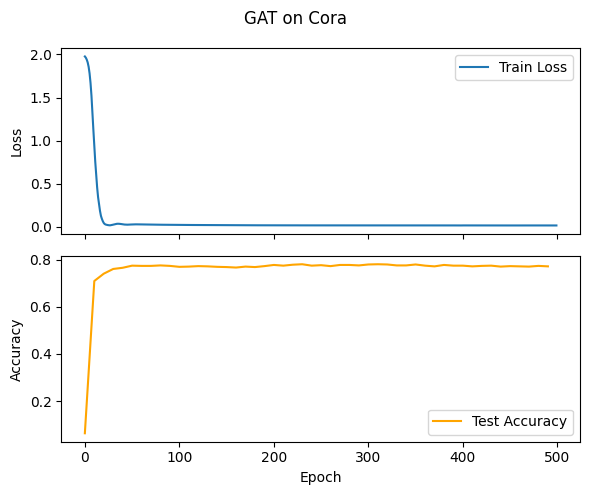

Training GraphSage on cora...
device =  cuda
Epoch 000, Train Loss: 1.9493, Test Acc: 0.1570
Epoch 010, Train Loss: 1.2444, Test Acc: 0.7360
Epoch 020, Train Loss: 0.3604, Test Acc: 0.7430
Epoch 030, Train Loss: 0.0537, Test Acc: 0.7650
Epoch 040, Train Loss: 0.0180, Test Acc: 0.7360
Epoch 050, Train Loss: 0.9960, Test Acc: 0.4920
Epoch 060, Train Loss: 0.0534, Test Acc: 0.6820
Epoch 070, Train Loss: 0.0295, Test Acc: 0.6880
Epoch 080, Train Loss: 0.0280, Test Acc: 0.6900
Epoch 090, Train Loss: 0.0320, Test Acc: 0.7130
Epoch 100, Train Loss: 0.0357, Test Acc: 0.7170
Epoch 110, Train Loss: 0.0365, Test Acc: 0.7110
Epoch 120, Train Loss: 0.0352, Test Acc: 0.7050
Epoch 130, Train Loss: 0.0340, Test Acc: 0.7000
Epoch 140, Train Loss: 0.0335, Test Acc: 0.6990
Epoch 150, Train Loss: 0.0333, Test Acc: 0.6980
Epoch 160, Train Loss: 0.0331, Test Acc: 0.6970
Epoch 170, Train Loss: 0.0329, Test Acc: 0.6980
Epoch 180, Train Loss: 0.0326, Test Acc: 0.6990
Epoch 190, Train Loss: 0.0324, Test Acc: 0.

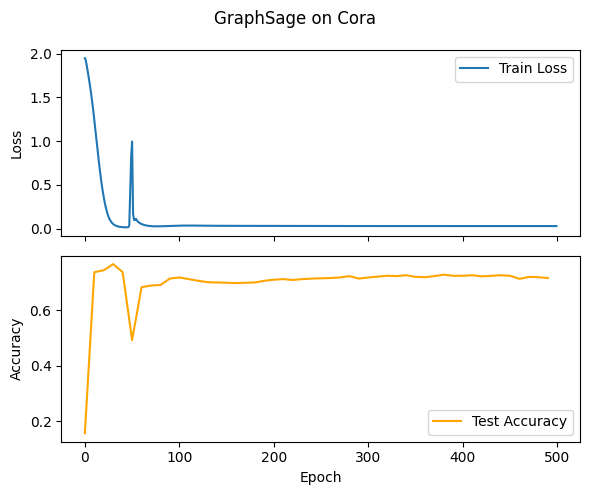

In [ ]:
for args in [
    {'model_type': 'GraphSage', 'dataset': 'cora', 'num_layers': 2, 'heads': 1, 'hidden_dim': 32, 'dropout': 0.5, 'epochs': 500, 'opt': 'adam', 'opt_scheduler': 'none', 'opt_restart': 0, 'weight_decay': 5e-3, 'lr': 0.01},
]:

    args = objectview(args)
    for model in ['GAT', 'GraphSage']:
        args.model_type = model

        # Match the dimension.
        if model == 'GAT':
          args.heads = 8
          args.hidden_dim = 4
        else:
          args.heads = 1
          args.hidden_dim = 32


        ############################################################################
        # TODO: Your code here!
        # Train the model and plot the training loss and test accuracy for both GAT and GraphSage
        ############################################################################
        print(f"Training {model} on {args.dataset}...")
        train_loss, test_acc = train(dataset, args)

        epochs = range(len(train_loss))
        test_epochs = range(0, len(train_loss), 10)

        fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6,5))

        ax1.plot(epochs, train_loss, label='Train Loss')
        ax1.set_ylabel('Loss')
        ax1.legend()

        ax2.plot(test_epochs, test_acc, label='Test Accuracy', color='orange')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.legend()

        plt.suptitle(f'{model} on Cora')
        plt.tight_layout()
        plt.show()




## Part 3: Questions

<u>You can just write your answers in the text box of each question.</u>

### Question 1: What is the best accuracy obtained on test set for GAT?
## 0.7800

Run the cells above and save your GAT model accuracy every ten epochs to the file *CORA-GAT.txt*.


### Question 2: What is the best accuracy obtained on test set for GraphSage?
## 0.7650


Run the cells above and save your GraphSage model accuracy every ten epochs to the file *CORA-GraphSage.txt*.

### Question 3: Increase the number of GNN layers and observe how the performance changes. Write down your observation and analysis.

Both GraphSAGE and GAT performance, dropped with deeper architecture level, showing low accuracy and unstable learning. The training loss got closer to 0, while test accuracy was lower with each iteration of decreasing number of layers. GAT maintained higher accuracy up to a certain number of layers than GraphSAGE, highlighting its attention capabilities, but once the layers were significantly large, both models seemed to overfit to the data and training accuracy was very low. They performed best with two layers, and with one, I think the model complexity fell just short to fully generalize to the data and perform the best. The test accuracy was still high, but it peaked on the second layer.

### Question 4: Change the number of attention heads and observe how the performance changes. Write down you observation and analysis.

GraphSAGE is not affected as it does not have attention heads.
Performance of GAT doesn't change much, and I assume this is because the dataset is quite simple and 2 attention heads provide a good representation of it already. However, with increased attention heads and hidden dimensions, we are able to achieve around 80 percent accuracy


---

## Submission Instructions

1. Complete all parts of the notebook.
2. Submit your completed notebook file (.ipynb), along with all other generated files to Canvas.

<font color='red'> **Note**: The uploaded notebook file (.ipynb) should contain **completed codes** and all **cell output**. </font>

## Additional Resources
- [PyTorch Documentation](https://pytorch.org/docs/stable/index.html)
- [Basics of PyTorch Geometric (PyG)](https://pytorch-geometric.readthedocs.io/en/latest/get_started/introduction.html)
- [Creating Message Passing Neural Network](https://pytorch-geometric.readthedocs.io/en/latest/tutorial/create_gnn.html)

If you have any questions, feel free to reach out during office hours or on the course forum.